In [4]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import mne
import re
os.chdir(r'D:\Thesis\ThesisEEG\ds003969-download')

In [5]:
sub = "036"         
task = "med1breath"  
base_path = r"D:\Thesis\ThesisEEG\ds003969-download"
bdf_path = fr"{base_path}\sub-{sub}\eeg\sub-{sub}_task-{task}_eeg.bdf"
raw = mne.io.read_raw_bdf(bdf_path, preload=True)

Extracting BDF parameters from D:\Thesis\ThesisEEG\ds003969-download\sub-036\eeg\sub-036_task-med1breath_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 622591  =      0.000 ...   607.999 secs...


In [6]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 72 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 208.0 Hz
 meas_date: 2010-01-21 15:03:20 UTC
 nchan: 73
 projs: []
 sfreq: 1024.0 Hz
 subject_info: <subject_info | his_id: >
>

Setting up band-pass filter from 1 - 50 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 50.00 Hz: -6.02, -6.02 dB



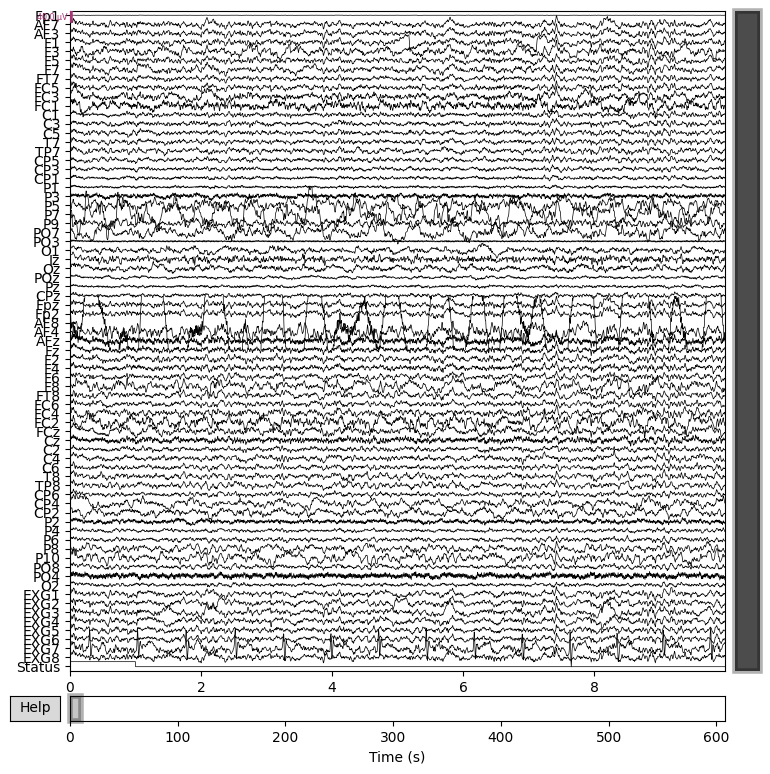

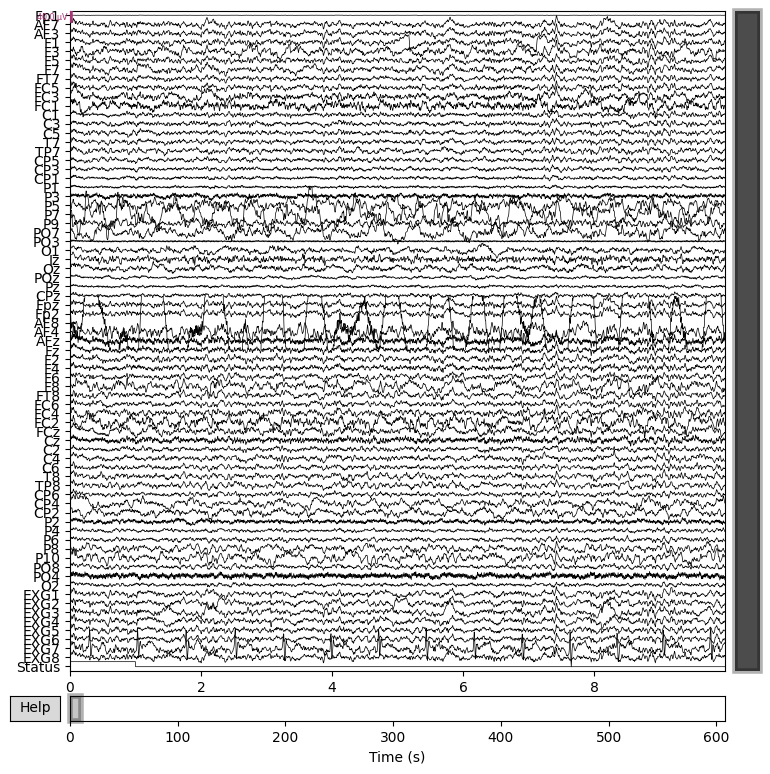

In [ ]:
raw.plot( n_channels=80, lowpass=50, highpass=1)

In [ ]:
raw.ch_names

['Fp1',
 'AF7',
 'AF3',
 'F1',
 'F3',
 'F5',
 'F7',
 'FT7',
 'FC5',
 'FC3',
 'FC1',
 'C1',
 'C3',
 'C5',
 'T7',
 'TP7',
 'CP5',
 'CP3',
 'CP1',
 'P1',
 'P3',
 'P5',
 'P7',
 'P9',
 'PO7',
 'PO3',
 'O1',
 'Iz',
 'Oz',
 'POz',
 'Pz',
 'CPz',
 'Fpz',
 'Fp2',
 'AF8',
 'AF4',
 'AFz',
 'Fz',
 'F2',
 'F4',
 'F6',
 'F8',
 'FT8',
 'FC6',
 'FC4',
 'FC2',
 'FCz',
 'Cz',
 'C2',
 'C4',
 'C6',
 'T8',
 'TP8',
 'CP6',
 'CP4',
 'CP2',
 'P2',
 'P4',
 'P6',
 'P8',
 'P10',
 'PO8',
 'PO4',
 'O2',
 'EXG1',
 'EXG2',
 'EXG3',
 'EXG4',
 'EXG5',
 'EXG6',
 'EXG7',
 'EXG8',
 'Status']

In [7]:
if {'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp'}.issubset(set(raw.ch_names)):
    raw.drop_channels (['GSR1','GSR2','Erg1','Erg2','Resp','Plet','Temp','Status', 'EXG7'])
else: 
    raw.drop_channels(['Status', 'EXG7']) 

In [8]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 71 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 208.0 Hz
 meas_date: 2010-01-21 15:03:20 UTC
 nchan: 71
 projs: []
 sfreq: 1024.0 Hz
 subject_info: <subject_info | his_id: >
>

Setting up band-pass filter from 1 - 50 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 50.00 Hz: -6.02, -6.02 dB



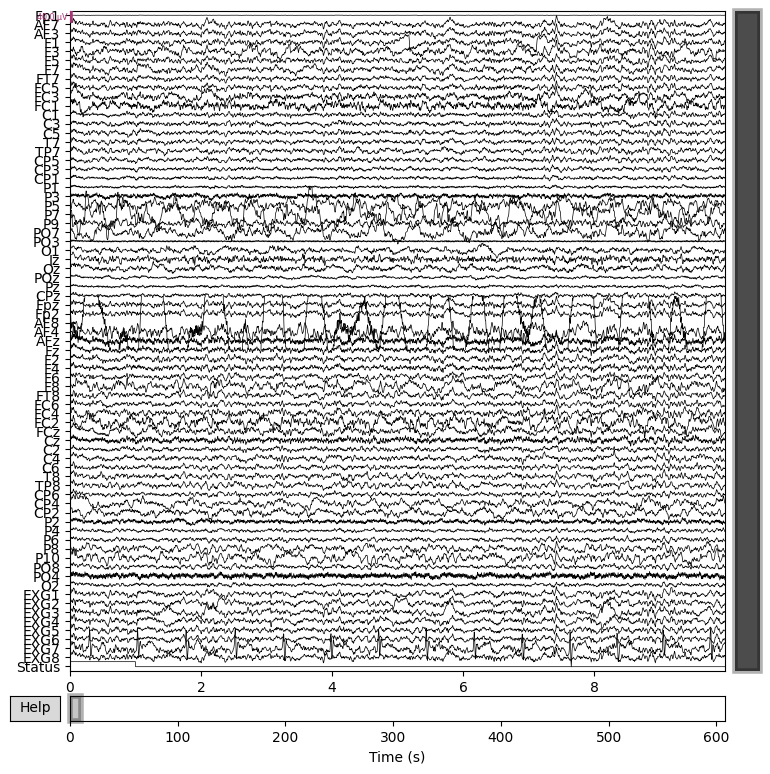

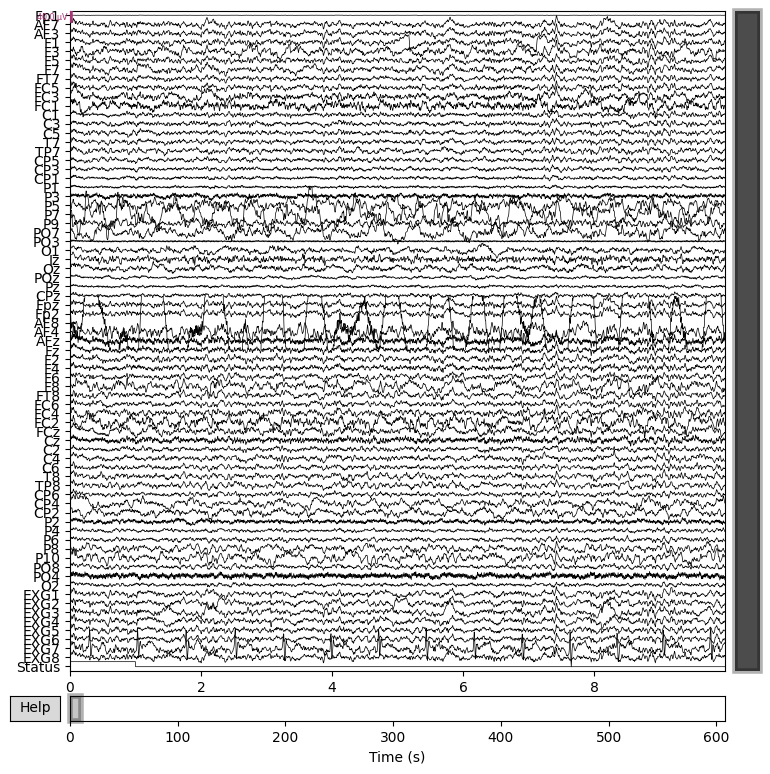

In [ ]:
raw.plot( n_channels=80, lowpass=50, highpass=1)

In [ ]:
mapping = {'EXG1': 'eog', 'EXG2': 'eog','EXG3': 'eog', 'EXG4': 'eog', 'EXG5': 'eeg', 'EXG6': 'eeg'}
raw.set_channel_types(mapping)

<RawBDF | sub-018_task-med1breath_eeg.bdf, 71 x 652288 (637.0 s), ~353.4 MiB, data loaded>

In [ ]:
# Set montage
USE_STANDARD_1020 = True
CHECK_MONTAGE = False

if USE_STANDARD_1020:
    mon = mne.channels.make_standard_montage('standard_1020')

    raw.set_channel_types({
        'EXG1': 'eog', 'EXG2': 'eog','EXG3': 'eog', 'EXG4': 'eog', 'EXG5': 'eeg', 'EXG6': 'eeg'
        
    })

    raw.set_montage(mon, on_missing='ignore')

else:
    print('creating custom montage...')
    pos = raw._get_channel_positions()

    ch_pos = {ch: p for ch, p in zip(raw.ch_names, pos)}
    montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame="head")

    raw.set_montage(montage, on_missing="ignore")

In [ ]:
# Montage sanity check
if CHECK_MONTAGE:
    raw.plot_sensors(kind="topomap")

    SUBJECTS_DIR = Path("data")  
    FS_SUBJECT = "fsaverage"

    os.environ["SUBJECTS_DIR"] = str(SUBJECTS_DIR)  # a temporary solution
    FS_SRC_FNAME = SUBJECTS_DIR / FS_SUBJECT / "bem" / "fsaverage-ico-4-src.fif"
    src = mne.read_source_spaces(FS_SRC_FNAME, verbose=False)

In [ ]:
 # Check that the locations of EEG electrodes is correct with the current montage
#mne.viz.plot_alignment(
    #raw.info,
    #eeg=True,
    #dig=True,
    #show_axes=True
#)

In [ ]:
#bandpass notch filter 
raw.filter(l_freq=1, h_freq=50, picks="eeg")

# Notch filter
raw = raw.notch_filter(
    freqs=[50],
    notch_widths=0.02,
    method="fir",
    picks="eeg",
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 3381 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.49
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.24 Hz)
- Upper passband edg

In [ ]:
#marks bad channels 
def mark_bads(raw, bads):
    if isinstance(bads, float) and np.isnan(bads):
        pass  # no bad channels

    elif isinstance(bads, str) and bads.startswith('['):
        # stringified list: "['P7', 'T8']"
        raw.info['bads'] = re.findall(r"'([^']+)'", bads)

    elif isinstance(bads, str):
        # single channel: 'O1'
        raw.info['bads'] = [bads]

    else:
        raise ValueError(f"Unexpected bad_channels entry: {bads}")
print (raw.info['bads'])

[]


In [ ]:
#ICA
from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs
raw.crop(tmax=60.0).pick(picks=[ "eeg"])
raw.load_data()

<RawBDF | sub-018_task-med1breath_eeg.bdf, 71 x 61441 (60.0 s), ~33.4 MiB, data loaded>

In [ ]:
ica=ICA(n_components=0.99, method="fastica", random_state=97)
ica.fit(raw, picks="eeg", reject_by_annotation=True)
raw_filt = raw.copy().filter(1., 40., picks=["eeg", "eog"])
eog_inds_v, scores_v = ica.find_bads_eog(raw_filt, ch_name=["EXG3", "EXG4"])
eog_inds_h, scores_h = ica.find_bads_eog(raw_filt, ch_name=["EXG1", "EXG2"])

eog_inds_v = [i for i in eog_inds_v if abs(scores_v[0][i]) >= 0.5] #also check the old one 
eog_inds_h = [i for i in eog_inds_h if abs(scores_h[0][i]) >= 0.5]

raw_filt = raw.copy().filter(1., 40., picks=["eeg", "eog"])
# Vertical EOG proxy: Fp1 - Cz
raw_filt = mne.set_bipolar_reference(raw_filt, "Fp1", "Cz", ch_name="VEOG", drop_refs=False) #check again
raw_filt.set_channel_types({'EXG3': 'eog', 'EXG4': 'eog'})

# Horizontal EOG proxy (optional): F7 - F8
raw_filt = mne.set_bipolar_reference(raw_filt, "F7", "F8", ch_name='HEOG', drop_refs=False)#check again
raw_filt.set_channel_types({ 'EXG1': 'eog', 'EXG2': 'eog'})

ica = mne.preprocessing.ICA(n_components=0.99, method="fastica", random_state=97)
ica.fit(raw_filt, picks="eeg", reject_by_annotation=True)

# TODO remove musle ICA
eog_inds_v, scores_v = ica.find_bads_eog(raw_filt, ch_name=["EXG3", "EXG4"])
eog_inds_h, scores_h = ica.find_bads_eog(raw_filt, ch_name=["EXG1", "EXG2"])

eog_inds_v = [i for i in eog_inds_v if abs(scores_v[0][i]) >= 0.5]
eog_inds_h = [i for i in eog_inds_h if abs(scores_h[0][i]) >= 0.5]

bad_ic = sorted(set(eog_inds_h + eog_inds_v)) #+ muscle_inds + ecg_inds

ica.exclude = bad_ic

raw_ica = ica.apply(raw_filt.copy())
raw_ica.drop_channels(['VEOG', 'HEOG']) #check again which channel I should drop

Fitting ICA to data using 67 channels (please be patient, this may take a while)
Selecting by explained variance: 27 components
Fitting ICA took 97.8s.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3381 samples (3.302 s)



C:\Users\tramy\AppData\Roaming\Python\Python313\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Using EOG channels: EXG3, EXG4
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.

C:\Users\tramy\AppData\Roaming\Python\Python313\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 s

<RawBDF | sub-018_task-med1breath_eeg.bdf, 71 x 61441 (60.0 s), ~33.4 MiB, data loaded>

In [ ]:
# interpolate bad channel 
if raw.info['bads']:
    epochs_clean.interpolate_bads()

In [ ]:
#rereferencing 
raw.set_eeg_reference('average', projection=False)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawBDF | sub-018_task-med1breath_eeg.bdf, 71 x 61441 (60.0 s), ~33.4 MiB, data loaded>

Setting up band-pass filter from 1 - 50 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 50.00 Hz: -6.02, -6.02 dB



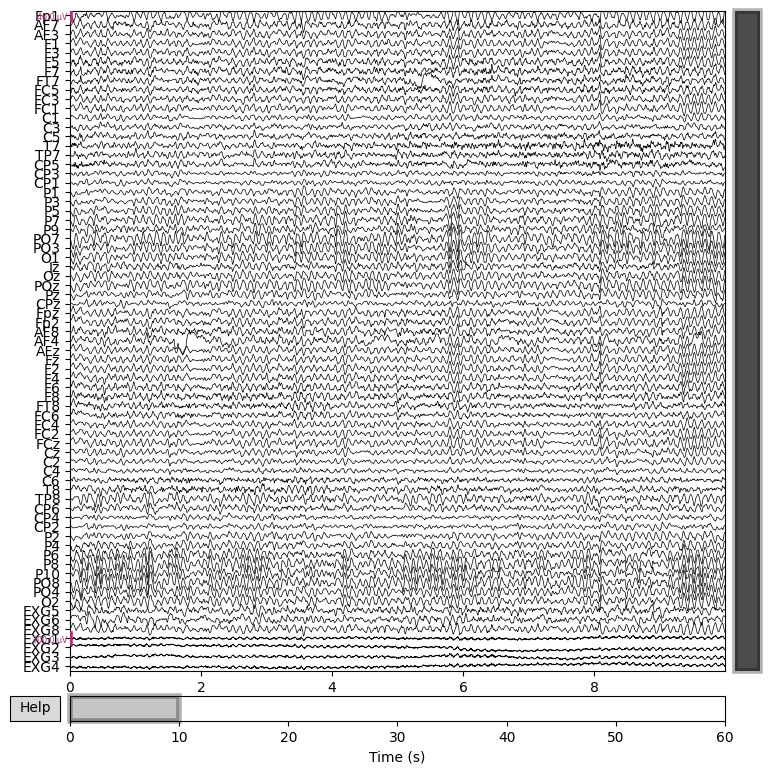

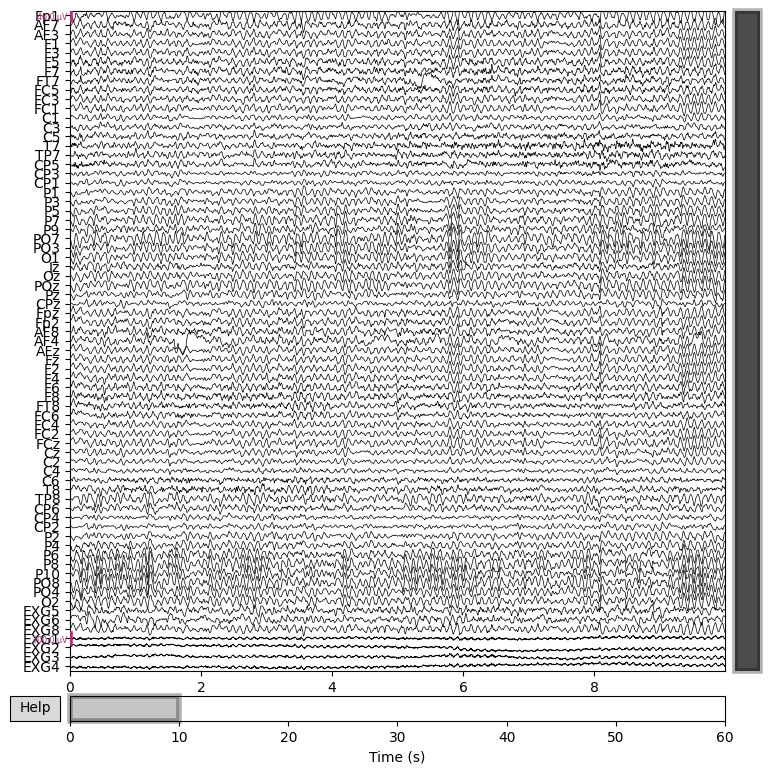

In [ ]:
raw.plot( n_channels=80, lowpass=50, highpass=1)